In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

/opt/homebrew/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [4]:
print(X_train.shape)  # (60000, 28, 28)
print(y_train.shape)  # (60000,)

(60000, 28, 28)
(60000,)


In [5]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

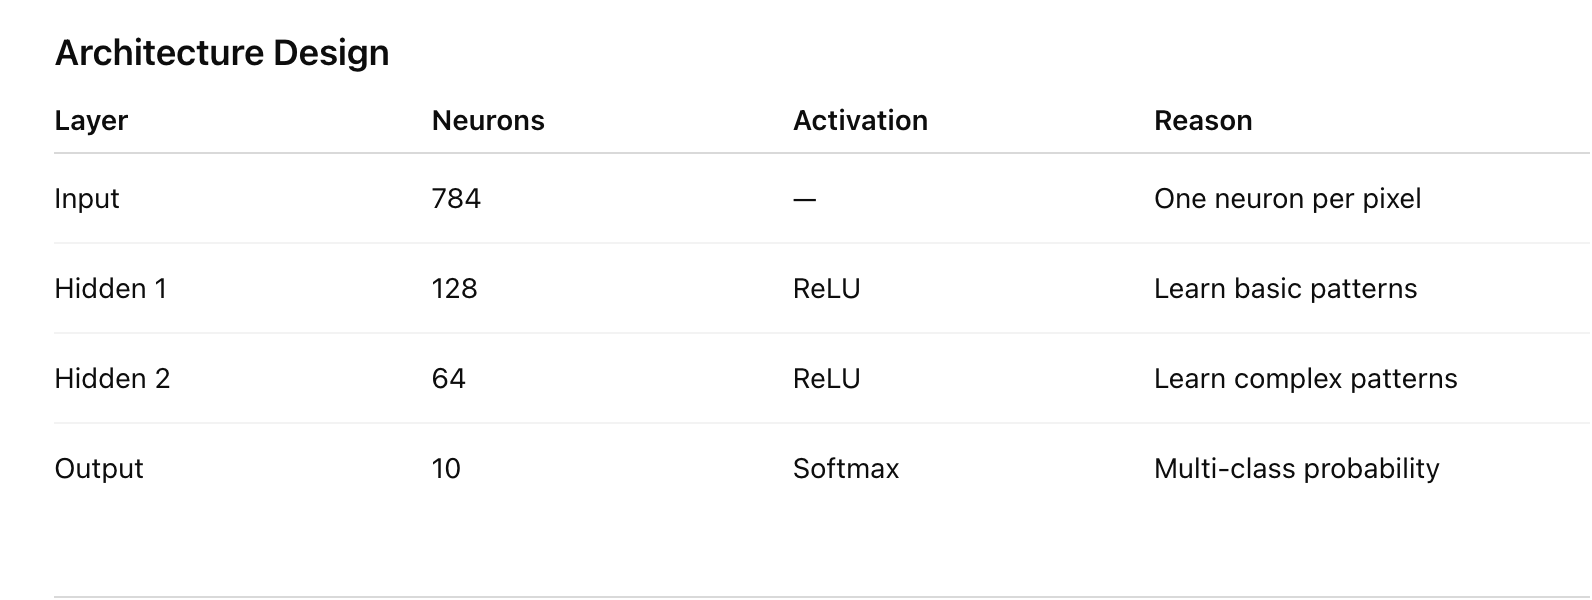

In [7]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
sample_preds = model(X_train[:5])
print(sample_preds)

tf.Tensor(
[[0.13419484 0.07555284 0.10981746 0.04302743 0.15004511 0.13919102
  0.09969894 0.10553122 0.08997034 0.05297096]
 [0.1398741  0.05786825 0.07377452 0.09342446 0.13775328 0.11444629
  0.06625141 0.14080913 0.09453187 0.08126666]
 [0.08614771 0.09172352 0.1138778  0.09330098 0.11301466 0.12570786
  0.07683587 0.11270843 0.08703751 0.09964562]
 [0.09880365 0.07100188 0.10907382 0.07991771 0.15593997 0.09953838
  0.09372954 0.12945339 0.10533436 0.05720735]
 [0.11084826 0.08556829 0.10750508 0.04513809 0.15213543 0.16145611
  0.09121483 0.08280491 0.11078675 0.05254226]], shape=(5, 10), dtype=float32)


In [9]:
loss = 'sparse_categorical_crossentropy'

In [10]:
optimizer = Adam(learning_rate=0.001)

In [11]:
model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)


In [12]:
(60000-6000)/128

421.875

In [13]:
60000/128

468.75

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9007 - loss: 0.3535 - val_accuracy: 0.9608 - val_loss: 0.1395
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9568 - loss: 0.1472 - val_accuracy: 0.9698 - val_loss: 0.1062
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9694 - loss: 0.1025 - val_accuracy: 0.9727 - val_loss: 0.0910
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9778 - loss: 0.0758 - val_accuracy: 0.9728 - val_loss: 0.0855
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9829 - loss: 0.0583 - val_accuracy: 0.9743 - val_loss: 0.0844
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9873 - loss: 0.0452 - val_accuracy: 0.9753 - val_loss: 0.0864
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9901 - loss: 0.0353 - val_accuracy: 0.9752 - val_loss: 0.0895
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9924 - loss: 0.0281 - val_accuracy: 0.

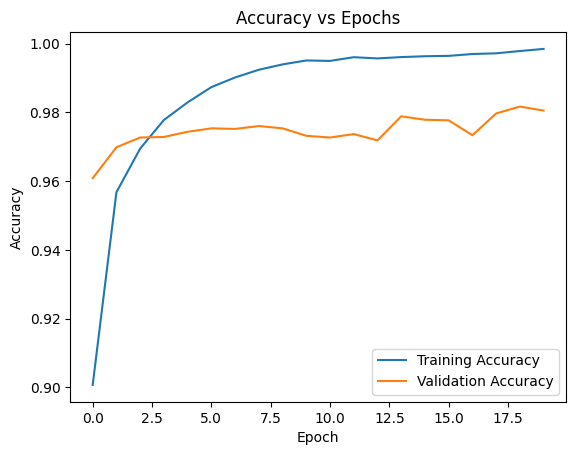

In [15]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')
plt.show()


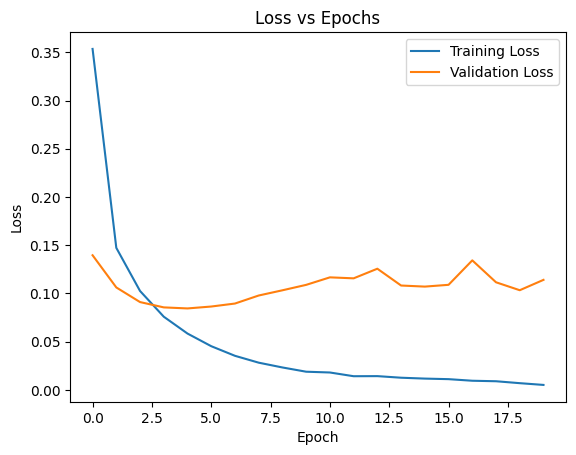

In [16]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()


In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - accuracy: 0.9761 - loss: 0.1070
Test Accuracy: 97.61%
